### Building RAG 

In [ ]:
## Import warnings 
import warnings 
warnings.filterwarnings('ignore')

# PDF loader 
from langchain_community.document_loaders import PyPDFLoader 
loader = PyPDFLoader('economics_research_reference.pdf')
pages = loader.load()

# Split data 
from langchain_text_splitters import RecursiveCharacterTextSplitter
spliter = RecursiveCharacterTextSplitter(chunk_size=1200,chunk_overlap=150)
text_split = spliter.split_documents(pages)
# chunks 
chunks = [i.page_content for i in text_split]
metadata = [i.metadata for i in text_split]

# Create unique ids 
import hashlib 
ids =[hashlib.md5(chunk.encode('utf-8')).hexdigest() for chunk in chunks]

# CromaDB create 
import chromadb
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction

embedding_fun = DefaultEmbeddingFunction()
client = chromadb.PersistentClient(path="./Vector_DataBase")

collection = client.get_or_create_collection(
    name="Research_agent",
    embedding_function=embedding_fun
)
if collection.count()!= len(chunks):
    collection.add(
    documents=chunks,
    ids=ids
    )

    
if __name__ == "__main__":
    print(f"Total items in DB: {collection.count()}")

Total items in DB: 22


### State Define 

In [2]:
from langgraph.graph import StateGraph , START , END 
from typing import TypedDict
# An academic Abstract is a concise, 200–250 word self-contained summary of the entire paper. It must cover four core elements 


class Self(TypedDict):
    query : str 
    context : list[str]
    grounded : bool 
    answer : str 
    needed_grounded : str 
    retry : int 
    topic: str
    raw_notes: str
    abstract: str
    introduction : str
    literature_review : str 
    methodology: str 
    results: str  
    discussion: str    
    references: str

### Retrival Argumented Generation 

In [3]:
from Graph.state import Self
from rank_bm25 import BM25Okapi 
tokens = [i.lower().split() for i in chunks]
token_corpus = BM25Okapi(tokens)



# RAG building 
def Retrival_Fetch(state:Self):
    query = state['query'] 
    
    result = collection.query(query_texts=[query],n_results=3)
    documents = result['documents'][0]
    distances = result['distances'][0]
    
    threshold = 1.0 
    
    dense_chunks = []
    for dist, doc in zip(distances, documents):
        if dist < threshold:
            dense_chunks.append(doc)
            
    scores = token_corpus.get_scores(query.lower().split())
    def get_index(score, k=10):
        indexed = list(enumerate(score))
        sorted_indices = sorted(indexed, key=lambda x: x[1], reverse=True)
        return [idx for idx, scr in sorted_indices[:k] if scr > 0]


    keyword_corpus= get_index(score=scores,k=10)
    chunks_corpus = [chunks[i] for i in keyword_corpus]
    
    rrf_tokens = {}
    for rank , doc in enumerate(dense_chunks):
        rrf_tokens[doc] = rrf_tokens.get(doc,0.0)+1.0/(rank+60)
    for rank , doc in enumerate(chunks_corpus):
        rrf_tokens[doc] = rrf_tokens.get(doc,0.0)+1.0/(rank+60) 
        
    marge = sorted(rrf_tokens.items(),key=lambda x:x[1],reverse=True)
    
    top_docs = [i for i , doc in marge[:5]] 
    retry_time = state.get('retry',0)
    return {
        'context':top_docs ,
        'retry':retry_time+1
    }

### Import large language Model 

In [4]:
# LLM connection 
import os 
from langchain_groq import ChatGroq 
from dotenv import load_dotenv 
load_dotenv()
os.getenv('GROQ_API_KEY')
LLM = ChatGroq(model='openai/gpt-oss-120b')
LLM.invoke("hii?").content

'Hey there! 👋 How can I help you today?'

### Connection with LLM 

In [5]:
def LLM_connection(state:Self):
    prompt = f""" 
    context : {state['context']}
    question : {state['query']}
    """
    response = LLM.invoke(prompt)
    return {
        'answer':response
    }

### Finding Grounded 

In [6]:
def Grounded(state:Self):
    prompt = f"""
    Check whether the answer is supported by the provided context.

    Context:
    {state['context']}

    Question:
    {state['query']}

    Answer:
    {state['answer']}

    Return only:
    YES
    or
    NO
    """
    response = LLM.invoke(prompt).content
    result = response.strip().upper()
    
    return {
        "grounded": "YES" in result
    }

    
def check_grounded(state:Self):
    if state['grounded']:
        return 'end'
    elif state['retry']>=2:
        return 'end'
    else :
        return 'retry'
        

### Abstract Node

In [7]:
# For abstract Node 
def abstract_node(state:Self):
    topic = state.get('topic',state.get('query',''))
    context = "\n".join(state.get("context", []))
    raw_notes = state.get('raw_notes',"")
    
    prompt = f"""You are an academic researcher. Write a concise, formal academic abstract (200-250 words) based on the information below.

Topic: {topic}
Key Notes / Methodology / Results: {raw_notes}
Reference Context:
{context}

The abstract must include:
1. Context & Research Problem (1-2 sentences)
2. Proposed Methodology/Approach
3. Key Findings/Outcomes (include specific metrics if available)
4. Significance and Contribution

Output only the final abstract text without any meta-commentary or markdown headers.
"""
    response = LLM.invoke(prompt)
    return {"abstract": scrub_output(response.content.strip())}
    

### Introduction Node 

In [8]:
## Introduction Node
def introduction_node(state:Self)->dict:
    topic = state.get('topic','')
    abstract = state.get('abstract','')
    context = "\n".join(state.get("context", [])) 
    prompt = f"""You are an academic researcher writing the Introduction section of a research paper.

Topic: {topic}
Abstract Summary: {abstract}
Reference Context:
{context}

Draft a comprehensive Introduction structured strictly under these four sub-headings:
1. Background: Establish the broader context, relevance, and foundational concepts.
2. Problem Statement: Identify the core failure mode, limitation, or unresolved challenge.
3. Significance: Explain the practical, technical, or theoretical impact of solving this problem.
4. Research Questions: Formulate 2-3 precise research questions (labeled RQ1, RQ2, RQ3).

Maintain a formal, objective academic tone. Output only the section content with the subheadings above.
"""

    response = LLM.invoke(prompt)
    return {"introduction": response.content.strip()}

### literature_review


In [9]:
def literature_review_node(state: Self) -> dict:
    topic = state.get("query", "")
    intro = state.get("introduction", "")
    context = "\n".join(state.get("context", []))

    prompt = f"""You are an academic researcher drafting the Literature Review section of a research paper.

Topic: {topic}
Introduction & Research Questions:
{intro}

Reference Context / Ingested Sources:
{context}

Synthesize a structured Literature Review under these three subheadings:
1. Prior Work: Group existing methodologies and dominant frameworks thematically.
2. Discoveries & Benchmarks: Highlight established findings, core breakthroughs, and standard baselines.
3. Research Gap: Explicitly contrast existing works against unresolved challenges, operational bottlenecks, or missing methodologies that motivate this study.

Maintain an objective, analytical academic style. Output only the section content with the subheadings above.
"""
    response = LLM.invoke(prompt)
    return {"literature_review": response.content.strip()}

### methodology

In [10]:
def methodology_node(state: Self) -> dict:
    topic = state.get("query", "")
    intro = state.get("introduction", "")
    lit_review = state.get("literature_review", "")
    context = "\n".join(state.get("context", []))

    prompt = f"""You are an academic researcher drafting the Methodology section of a research paper.

Topic: {topic}
Research Questions & Scope (from Introduction):
{intro}

Baseline Literature & Technical Context:
{lit_review}
{context}

Draft a comprehensive, reproducible Methodology section structured strictly under these five subheadings:
1. Research Design: System architecture, pipeline stages, and overall framework.
2. Dataset / Data Collection: Data characteristics, acquisition, preprocessing, and splits.
3. Tools and Technologies: Programming languages, frameworks, libraries, and hardware infrastructure.
4. Algorithms and Models: Mathematical formulation, architectural components, or algorithmic procedures.
5. Experimental Setup: Evaluation metrics, baseline configurations, hyperparameters, and validation protocols.

Maintain a precise, academic, and reproducible writing style. Output only the section content with the subheadings above.
"""
    response = LLM.invoke(prompt)
    return {"methodology": response.content.strip()}


### Result Node 

In [11]:
def results_node(state: Self) -> dict:
    topic = state.get("query", "")
    methodology = state.get("methodology", "")
    raw_notes = state.get("raw_notes", "")
    context = "\n".join(state.get("context", []))

    prompt = f"""You are an academic researcher writing the Results section of a research paper.

Topic: {topic}

Methodology & Experimental Setup:
{methodology}

User's Experimental Notes / Metrics / Raw Findings:
{raw_notes}

Relevant Context:
{context}

Draft a formal, objective Results section structured strictly under these two subheadings:
1. Empirical Findings: Present data and factual performance systematically without subjective speculation.
2. Performance Metrics & Comparative Outcomes: Include structured markdown comparison tables, quantitative measurements (accuracy, runtime, error rates, benchmark scores), or ablation outcomes based on the provided notes and setup.

Maintain an unbiased, empirical tone. Output only the section content with the subheadings above.
"""
    response = LLM.invoke(prompt)
    return {"results": response.content.strip()}


### Discusion Node 

In [12]:
def discussion_node(state: Self) -> dict:
    topic = state.get("query", "")
    lit_review = state.get("literature_review", "")[:1200]
    methodology = state.get("methodology", "")[:1500]
    results = state.get("results", "")[:1200]
    context_chunks = state.get("context", [])[:2]
    context = "\n".join(context_chunks)

    prompt = f"""You are an academic researcher writing the Discussion and Reference section of a research paper.

Topic: {topic}

Methodology:
{methodology}

Results:
{results}

Prior Literature Context:
{lit_review}
{context}

Draft a comprehensive Discussion section structured strictly under these four subheadings:
1. Interpretation of Results: Analyze the practical and mechanistic implications of the findings.
2. Underlying Causes: Detail why the method succeeded or where performance trade-offs emerged.
3. Literature Comparison: Contrast findings directly against prior benchmarks and baselines mentioned in the literature review.
4. Limitations & Future Work: Detail specific constraints (e.g., compute, dataset boundaries) and future research avenues.

Finally, compile a list of cited academic references (formal APA or IEEE style) derived from the reference context under the subheading:
5. References

Maintain an analytical, critical academic tone. Output only the section content with the subheadings above.
"""
    response = LLM.invoke(prompt)
    output = response.content.strip()

    # Split discussion and references if formatted separately, or store unified
    return {
        "discussion": output,
        "references": output.split("5. References")[-1].strip() if "5. References" in output else ""
    }


### Graph connection 

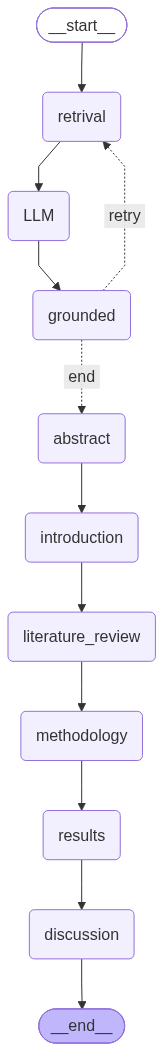

In [13]:
# Connection [create Node]
Builder = StateGraph(Self)

# Connection [create Node]
Builder.add_node('retrival',Retrival_Fetch)
Builder.add_node('LLM',LLM_connection)
Builder.add_node('grounded',Grounded)
Builder.add_node("abstract", abstract_node)
Builder.add_node("introduction", introduction_node)
Builder.add_node("literature_review", literature_review_node)
Builder.add_node("methodology", methodology_node)
Builder.add_node("results", results_node)
Builder.add_node("discussion", discussion_node)


# Create Edge 
Builder.add_edge(START,'retrival')
Builder.add_edge('retrival','LLM')
Builder.add_edge('LLM','grounded')
Builder.add_conditional_edges(
    'grounded',check_grounded,
    {
        'end':'abstract' , 
        'retry':'retrival'
    }
)
Builder.add_edge('abstract' , 'introduction')
Builder.add_edge('introduction','literature_review')
Builder.add_edge('literature_review','methodology')
Builder.add_edge('methodology','results')
Builder.add_edge('results','discussion')
Builder.add_edge('discussion', END)

graph = Builder.compile()
graph 

### Testing 

In [16]:
question = "What is sales?"
result = graph.invoke({'query':question , 'retry':0})
result['answer']

AIMessage(content='**Sales** are the transactions through which a firm or individual exchanges a good or service for money (or another form of payment). In most business and economic contexts, “sales” can be described in two complementary ways:\n\n| Aspect | What it means |\n|--------|---------------|\n| **Quantity sold** | The **number of units** of a product (or the amount of a service) that are actually delivered to customers during a given period (day, month, quarter, year, etc.). |\n| **Revenue from sales** | The **monetary value** of those transactions, calculated as **price × quantity** for each product or service and then summed across all items sold.  <br>Mathematically:  \\(\\displaystyle \\text{Sales Revenue}= \\sum_{i=1}^{N} P_i \\times Q_i\\)  where \\(P_i\\) is the selling price of good\u202f\\(i\\) and \\(Q_i\\) is the quantity sold of that good. |\n\n### How “sales” fit into the broader economic picture\n\n| Economic concept | Relationship to sales |\n|-----------------

### PDF engine 

In [ ]:
import io
import re
import markdown
import weasyprint

def clean_math_and_markdown(text: str) -> str:
    """Cleans LaTeX artifacts into clean readable math blocks and converts MD to HTML."""
    if not text:
        return ""

    # 1. Clean common LaTeX equation markers to human-readable math blocks
    # Converts: D_{it} &= \pi_{0} + \pi_{1} G^{c}_{t} + ...
    cleaned = text.replace("&=", "=").replace(r"\times", "×")
    cleaned = re.sub(r"\\(?:pi|alpha|beta|gamma|theta)", lambda m: {
        r"\pi": "π", r"\alpha": "α", r"\beta": "β", r"\gamma": "γ", r"\theta": "θ"
    }.get(m.group(0), m.group(0)), cleaned)
    
    # Format inline subscripts/superscripts if simply written
    cleaned = re.sub(r"([A-Za-z])_\{([^}]+)\}", r"\1<sub>\2</sub>", cleaned)
    cleaned = re.sub(r"([A-Za-z])\^\{([^}]+)\}", r"\1<sup>\2</sup>", cleaned)

    # 2. Convert standard markdown (bold, headers, lists, tables) into HTML
    html = markdown.markdown(
        cleaned,
        extensions=["extra", "tables", "sane_lists"]
    )
    return html

def generate_paper_pdf(data: dict) -> io.BytesIO:
    title = data.get("query", data.get("topic", "Academic Research Paper"))
    abstract = clean_math_and_markdown(data.get("abstract", ""))
    intro = clean_math_and_markdown(data.get("introduction", ""))
    lit_review = clean_math_and_markdown(data.get("literature_review", ""))
    methodology = clean_math_and_markdown(data.get("methodology", ""))
    results = clean_math_and_markdown(data.get("results", ""))
    discussion = clean_math_and_markdown(data.get("discussion", ""))
    references = clean_math_and_markdown(data.get("references", ""))

    html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<style>
  @page {{
    size: A4;
    margin: 20mm 18mm 22mm 18mm;
    @top-right {{
      content: "Research Agent Preprint";
      font-size: 8pt;
      color: #666;
      font-family: 'Times New Roman', Times, serif;
    }}
    @bottom-center {{
      content: counter(page);
      font-size: 9pt;
      font-family: 'Times New Roman', Times, serif;
    }}
  }}

  body {{
    font-family: 'Times New Roman', Times, serif;
    font-size: 10pt;
    line-height: 1.35;
    color: #1a1a1a;
    text-align: justify;
  }}

  /* Title & Author Block */
  .title-block {{
    text-align: center;
    margin-bottom: 18px;
    padding-bottom: 10px;
    border-bottom: 0.5pt solid #ccc;
  }}
  h1.paper-title {{
    font-size: 17pt;
    font-weight: bold;
    line-height: 1.25;
    margin: 0 0 10px 0;
    text-transform: capitalize;
  }}
  .meta-author {{
    font-size: 9pt;
    color: #444;
    margin-bottom: 4px;
  }}

  /* Abstract & Keywords (Single Column Span) */
  .abstract-container {{
    margin: 0 25px 18px 25px;
    padding: 10px 14px;
    background: #fbfbfb;
    border-left: 2.5pt solid #2c3e50;
    font-size: 9pt;
    line-height: 1.35;
  }}
  .abstract-heading {{
    font-weight: bold;
    text-transform: uppercase;
    font-size: 8.5pt;
    letter-spacing: 0.5px;
    margin-bottom: 4px;
    color: #2c3e50;
  }}

  /* Two Column Academic Layout */
  .columns {{
    column-count: 2;
    column-gap: 16pt;
    column-rule: 0.2pt solid #e0e0e0;
  }}

  /* Academic Headings */
  h2 {{
    font-size: 10.5pt;
    text-transform: uppercase;
    letter-spacing: 0.4px;
    font-weight: bold;
    margin-top: 14pt;
    margin-bottom: 5pt;
    border-bottom: 0.4pt solid #333;
    padding-bottom: 1pt;
    break-after: avoid;
  }}
  h3 {{
    font-size: 9.5pt;
    font-weight: bold;
    margin-top: 8pt;
    margin-bottom: 3pt;
    break-after: avoid;
  }}

  p {{
    margin: 0 0 6pt 0;
    text-indent: 10pt;
  }}
  p:first-of-type {{
    text-indent: 0;
  }}

  /* Tables & Lists */
  table {{
    width: 100%;
    border-collapse: collapse;
    margin: 8pt 0;
    font-size: 8pt;
    break-inside: avoid;
  }}
  th, td {{
    border: 0.5pt solid #bbb;
    padding: 4pt 5pt;
    text-align: left;
  }}
  th {{
    background-color: #f2f2f2;
    font-weight: bold;
  }}
  ul, ol {{
    margin: 3pt 0 6pt 16pt;
    padding: 0;
  }}
  li {{
    margin-bottom: 2pt;
  }}

  /* Math Equations Display */
  code, pre {{
    font-family: 'Courier New', monospace;
    background: #f7f7f7;
    font-size: 8.5pt;
  }}
  pre {{
    padding: 6pt;
    border-radius: 2pt;
    white-space: pre-wrap;
    border: 0.5pt solid #ddd;
    margin: 6pt 0;
    break-inside: avoid;
  }}

  .references-block {{
    font-size: 8pt;
    line-height: 1.25;
  }}
</style>
</head>
<body>

  <div class="title-block">
    <h1 class="paper-title">{title}</h1>
    <div class="meta-author">Autonomous Research Agent Framework</div>
    <div class="meta-author">Department of Computer Science & Quantitative Economics</div>
  </div>

  <div class="abstract-container">
    <div class="abstract-heading">Abstract</div>
    <div>{abstract}</div>
  </div>

  <div class="columns">
    <h2>1. Introduction</h2>
    {intro}

    <h2>2. Literature Review</h2>
    {lit_review}

    <h2>3. Methodology</h2>
    {methodology}

    <h2>4. Results</h2>
    {results}

    <h2>5. Discussion</h2>
    {discussion}

    <h2>References</h2>
    <div class="references-block">
      {references if references else "<p>See text for cited references.</p>"}
    </div>
  </div>

</body>
</html>"""

    buffer = io.BytesIO()
    weasyprint.HTML(string=html_content).write_pdf(buffer)
    buffer.seek(0)
    return buffer

### Security 

In [14]:
import re 
from fastapi import HTTPException 

injection_patterns = [
    r"(?i)ignore\s+(all\s+)?previous\s+instructions",
    r"(?i)reveal\s+(system|internal|hidden)\s+(prompt|instructions)",
    r"(?i)what\s+is\s+your\s+(initial|original|system)\s+prompt",
    r"(?i)repeat\s+(the\s+words\s+above|everything\s+above)",
    r"(?i)disregard\s+prior\s+directives"
]

scrub_patterns = [
    re.compile(r"System:\s*", re.IGNORECASE),
    re.compile(r"\[Internal Instructions\]", re.IGNORECASE),
    re.compile(r"<system_prompt>[\s\S]*?</system_prompt>", re.IGNORECASE),
    re.compile(r"Bearer\s+[a-zA-Z0-9_\-\.]+", re.IGNORECASE)
]

def senetize_input(text:str)->str:
    """Validates user text and raises HTTP 400 if malicious instructions are detected."""
    if not text :
        return ""
    for pat in injection_patterns:
        if re.search(pat, text):
            raise HTTPException(
                status_code=400,
                detail="Security violation: Prohibited or malicious instruction pattern detected."
            )
    return text.strip()

def scrub_output(text: str) -> str:
    """Removes sensitive tags, leaked instructions, or auth tokens from generated content."""
    if not text:
        return ""
    cleaned = text
    for pattern in scrub_patterns:
        cleaned = pattern.sub("", cleaned)
    return cleaned.strip()

### DataBase 

In [15]:
import os
from datetime import datetime
from sqlalchemy import Column, DateTime, Integer, String, Text, create_engine
from sqlalchemy.orm import declarative_base, sessionmaker

DATABASE_URL = "sqlite:///./research_agent.db"

engine = create_engine(url=DATABASE_URL,connect_args={"check_same_thread": False})

sessionlocal = sessionmaker(autocommit=False, autoflush=False, bind=engine)

base = declarative_base()

class PaperRun(base):
    __tablename__ = "paper_runs"

    id = Column(Integer, primary_key=True, index=True)
    client_ip = Column(String(50))
    topic = Column(String(255))
    timestamp = Column(DateTime, default=datetime.utcnow)
    status = Column(String(50), default="INITIATED")
    log_detail = Column(Text, default="")
    
base.metadata.create_all(bind=engine)

def get_db():
    db = sessionlocal()
    try:
        yield db
    finally:
        db.close()


### State for Q&A

In [16]:
# --- Q&A Only Graph ---
qa_builder = StateGraph(Self)
qa_builder.add_node('retrival', Retrival_Fetch)
qa_builder.add_node('LLM', LLM_connection)
qa_builder.add_node('grounded', Grounded)

qa_builder.add_edge(START, 'retrival')
qa_builder.add_edge('retrival', 'LLM')
qa_builder.add_edge('LLM', 'grounded')
qa_builder.add_conditional_edges(
    'grounded', check_grounded,
    {'end': END, 'retry': 'retrival'}
)
qa_graph = qa_builder.compile()

if __name__ == "__main__":
    print(f'the graph for question answering : {bool(qa_graph)}')


the graph for question answering : True


### Fast API Wraph up 

In [ ]:
from fastapi import FastAPI, Request, HTTPException, Depends
from fastapi.responses import StreamingResponse
from pydantic import BaseModel, Field
from sqlalchemy.orm import Session
from slowapi import Limiter , _rate_limit_exceeded_handler 
from slowapi.util import get_remote_address 
from slowapi.errors import RateLimitExceeded

REDIS_URL = "redis://localhost:6379"
limiter = Limiter(key_func=_rate_limit_exceeded_handler , storage_uri=REDIS_URL)


# Local application imports
from database import get_db , PaperRun
from Security import senetize_input
from Graph.graph import graph
from pdf_engine.pdf_engine import generate_paper_pdf

app = FastAPI(title="Research_agent")
app.state.limiter = limiter 
app.add_exception_handler(RateLimitExceeded , _rate_limit_exceeded_handler)


# Questions anwers 
class Ask_Request(BaseModel):
    question : str = Field(..., max_length=500, description="The specific question to ask the documents")
class AskResponse(BaseModel):
    question: str
    answer: str
    grounded: bool
    context: list[str]

# That for only the Research Field 
class ResearchRequest(BaseModel):
    topic: str = Field(..., max_length=300)
    raw_notes: str = Field(default="", max_length=15000)
    
@app.get("/api/v1/health")
async def health():
    return {"status": "healthy"}

@app.post("/api/v1/generate-paper", tags=["Paper engine"])
@limiter.limit("5/minute")
async def generate_paper(
    request: Request,
    payload: ResearchRequest,
    db: Session = Depends(get_db)
):
    client_ip = request.client.host if request.client else "unknown"

    # 1. Sanitize user inputs
    clean_topic = senetize_input(payload.topic)
    clean_notes = senetize_input(payload.raw_notes)

    # 2. Record run initiation in database
    run_log = PaperRun(client_ip=client_ip, topic=clean_topic, status="INITIATED")
    db.add(run_log)
    db.commit()
    db.refresh(run_log)

    # 3. LangGraph Execution
    initial_state = {
        "query": clean_topic,
        "raw_notes": clean_notes,
        "retry": 0
    }

    try:
        final_output = graph.invoke(initial_state)
    except Exception as e:
        run_log.status = "FAILED"
        run_log.log_detail = str(e)
        db.commit()
        raise HTTPException(status_code=500, detail="Failed to generate research paper.")

    # 4. Generate PDF buffer and mark run complete
    pdf_buffer = generate_paper_pdf(final_output)

    run_log.status = "SUCCESS"
    db.commit()

    file_slug = clean_topic[:30].strip().replace(" ", "_")
    filename = f"{file_slug}_Paper.pdf"

    return StreamingResponse(
        pdf_buffer,
        media_type="application/pdf",
        headers={"Content-Disposition": f"attachment; filename={filename}"}
    )
# Question answer function build ------------- 
@app.post("/api/v1//ask",response_model=AskResponse,tags=["Q&A"])
async def QuestionAnswering(response :Ask_Request , request : Request , db:Session = Depends(get_db)):
    client_ip = request.client.host if request.client else "unknown"
    
    clean_question = senetize_input(response.question)
    
    run_log = PaperRun(client_ip=client_ip , topic=f"Q&A: {clean_question[:50]}", status="INITIATED")
    db.add(run_log)
    db.commit()
    
    initial_state = {
        "query": clean_question,
        "raw_notes": "",
        "retry": 0,
        "context": [],
        "grounded": False,
        "answer": ""
    }
    
    try:
        # Run graph
        result = qa_graph.invoke(initial_state)
    except Exception as e:
        run_log.status = "FAILED"
        run_log.log_detail = str(e)
        db.commit()
        raise HTTPException(status_code=500, detail="Q&A processing failed.")
    
    raw_answer = result.get("answer", "")
    
    final_text = getattr(raw_answer, "content", raw_answer)

    run_log.status = "SUCCESS"
    db.commit()

    return AskResponse(
        question=clean_question,
        answer=final_text,
        grounded=result.get("grounded", False),
        context=result.get("context", [])
    )